# Project 2: Forex Analysis & Prediction

In [1]:
!pip install yfinance


In [2]:
import yfinance as yf

data = yf.download("EURUSD=X", start="2020-01-01", end="2026-01-01")
data.head(10)

/tmp/ipykernel_10397/2895165850.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("EURUSD=X", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2020-01-01,1.122083,1.122838,1.115947,1.122083,0
2020-01-02,1.122083,1.122712,1.116682,1.121894,0
2020-01-03,1.117144,1.118068,1.112570,1.117081,0
2020-01-06,1.116196,1.120825,1.115810,1.116246,0
2020-01-07,1.119799,1.119946,1.113487,1.119583,0
2020-01-08,1.115474,1.116520,1.111086,1.115573,0
2020-01-09,1.111321,1.112223,1.109509,1.111444,0
2020-01-10,1.111111,1.112100,1.108623,1.110926,0


In [3]:
import yfinance as yf

# Download Gold data (XAUUSD)
gold = yf.download("GC=F", start="2020-01-01", end="2026-01-01")

gold.head(10)

/tmp/ipykernel_10397/1962424938.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214
2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107
2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416
2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47
2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236
2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54
2020-01-10,1557.500000,1558.800049,1545.400024,1551.199951,16
2020-01-13,1548.400024,1558.000000,1548.400024,1557.400024,48


In [4]:
import yfinance as yf

# Download BTC data
btc = yf.download("BTC-USD", start="2020-01-01", end="2026-01-01")

btc.head(100)

/tmp/ipykernel_10397/3112200367.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
...,...,...,...,...,...
2020-04-05,6791.129395,6883.414062,6715.929199,6862.537598,29510409856
2020-04-06,7271.781250,7271.781250,6782.889648,6788.049805,46896904615


1. Make the data clearly structured

In [5]:
import pandas as pd

# EURUSD
print(data.head())
print(data.columns)  # usually: Index(['Open','High','Low','Close','Adj Close','Volume'], ...)

# Keep a clean copy
eurusd = data.copy()
eurusd.index.name = 'timestamp'

# Gold (XAU proxy)
print(gold.head())
print(gold.columns)

xau = gold.copy()
xau.index.name = 'timestamp'

Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2020-01-01  1.122083  1.122838  1.115947  1.122083        0
2020-01-02  1.122083  1.122712  1.116682  1.121894        0
2020-01-03  1.117144  1.118068  1.112570  1.117081        0
2020-01-06  1.116196  1.120825  1.115810  1.116246        0
2020-01-07  1.119799  1.119946  1.113487  1.119583        0
MultiIndex([( 'Close', 'EURUSD=X'),
            (  'High', 'EURUSD=X'),
            (   'Low', 'EURUSD=X'),
            (  'Open', 'EURUSD=X'),
            ('Volume', 'EURUSD=X')],
           names=['Price', 'Ticker'])
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.1999

2. Build features for one case (EURUSD 4H or 1D)

In [6]:
import numpy as np
import pandas as pd

df = eurusd.copy()
# Flatten MultiIndex columns to single level for easier access
df.columns = df.columns.get_level_values('Price')

# ======================
# TREND FEATURES
# ======================
for window in [20, 50, 100]:
    df[f'ma_{window}'] = df['Close'].rolling(window=window).mean()

for window in [20, 50]:
    df[f'ma_{window}_slope'] = df[f'ma_{window}'].diff()

df['trend_up'] = (df['ma_20'] > df['ma_50']).astype(int)

# ======================
# VOLATILITY FEATURES
# ======================
df['ret'] = df['Close'].pct_change()
df['vol_20'] = df['ret'].rolling(window=20).std()

# True Range (ATR calculation)
high_low = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift(1)).abs()
low_close = (df['Low'] - df['Close'].shift(1)).abs()

tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)

df['atr_14'] = tr.rolling(window=14).mean()

# ======================
# STRUCTURE FEATURES
# ======================
window_sr = 50

df['rolling_low'] = df['Low'].rolling(window_sr).min()
df['rolling_high'] = df['High'].rolling(window_sr).max()

range_span = df['rolling_high'] - df['rolling_low']

# Avoid division by zero (this WILL happen eventually)
df['pos_in_range'] = np.where(
    range_span != 0,
    (df['Close'] - df['rolling_low']) / range_span,
    0
)

df['pos_in_range'] = df['pos_in_range'].clip(0, 1)

# Structure zones
df['structure_zone'] = 0
df.loc[df['pos_in_range'] < 0.2, 'structure_zone'] = 1     # support
df.loc[df['pos_in_range'] > 0.8, 'structure_zone'] = -1    # resistance

# ======================
# TARGET (NO LEAKAGE)
# ======================
df['close_next'] = df['Close'].shift(-1)
df['future_ret_1'] = df['close_next'] / df['Close'] - 1

df['target_up'] = (df['future_ret_1'] > 0).astype(int)

# ======================
# FINAL CLEANING
# ======================
df = df.dropna().reset_index(drop=True)

In [7]:


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols = [
    'ma_20', 'ma_50', 'ma_100',
    'ma_20_slope', 'ma_50_slope',
    'vol_20', 'atr_14',
    'pos_in_range', 'structure_zone'
]

X = df[feature_cols]
y = df['target_up']

# Time-series split: keep order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.4880546075085324

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.58      0.54       151
           1       0.47      0.39      0.43       142

    accuracy                           0.49       293
   macro avg       0.48      0.49      0.48       293
weighted avg       0.49      0.49      0.48       293


Confusion Matrix:
 [[87 64]
 [86 56]]


Feature Importances:
pos_in_range: 0.1542
ma_20_slope: 0.1282
vol_20: 0.1229
ma_50_slope: 0.1217
ma_20: 0.1213
atr_14: 0.1211
ma_50: 0.1135
ma_100: 0.1074
structure_zone: 0.0097


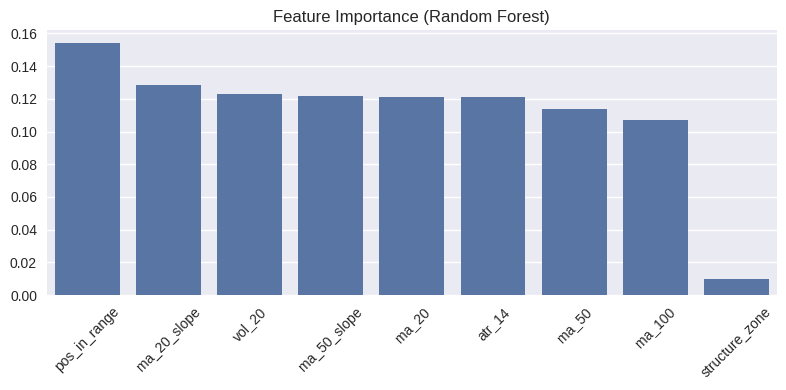

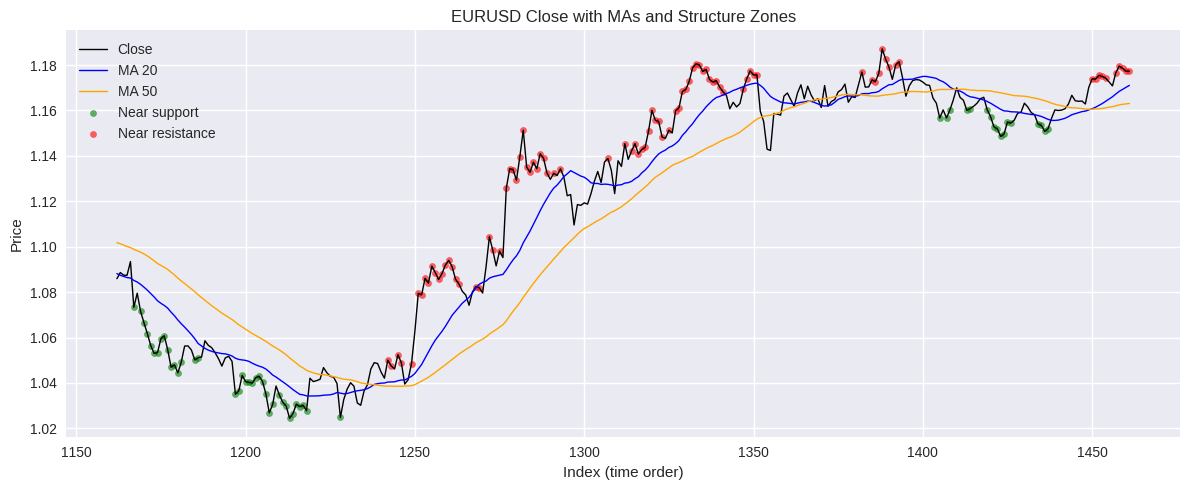

Price     ma_20     ma_50    ma_100  ma_20_slope  ma_50_slope    vol_20  \
1452   1.162203  1.160709  1.164516     0.000820     0.000089  0.002380   
1453   1.163044  1.160898  1.164714     0.000842     0.000190  0.002369   
1454   1.164052  1.161119  1.165027     0.001008     0.000221  0.002178   
1455   1.165008  1.161437  1.165329     0.000956     0.000318  0.002217   
1456   1.166010  1.161649  1.165451     0.001002     0.000211  0.002161   
1457   1.167240  1.162047  1.165632     0.001229     0.000398  0.002346   
1458   1.168393  1.162434  1.165849     0.001153     0.000386  0.002278   
1459   1.169309  1.162712  1.165971     0.000916     0.000278  0.002250   
1460   1.170174  1.162858  1.166067     0.000864     0.000146  0.002279   
1461   1.171031  1.163089  1.166192     0.000857     0.000231  0.002281   

Price    atr_14  pos_in_range  structure_zone  y_true  y_pred     Close  
1452   0.005533      0.850280              -1       0       0  1.175461  
1453   0.005551      0.835

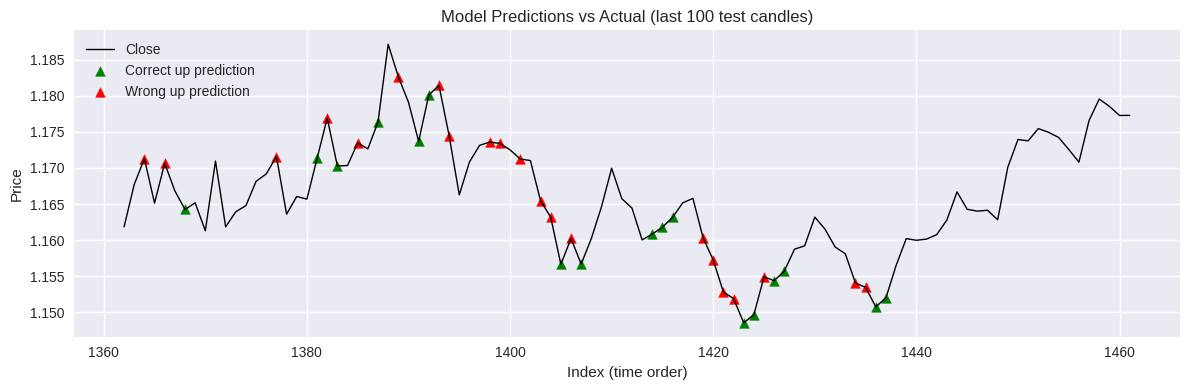

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# -------------------------
# 1. Feature importance
# -------------------------
importances = model.feature_importances_
fi = sorted(zip(feature_cols, importances), key=lambda x: -x[1])

print("Feature Importances:")
for name, val in fi:
    print(f"{name}: {val:.4f}")

plt.figure(figsize=(8, 4))
sns.barplot(x=[f[0] for f in fi], y=[f[1] for f in fi])
plt.xticks(rotation=45)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

# -------------------------
# 2. Price + moving averages + structure zones
# -------------------------
# Plot the last 300 candles from the full df (not only train/test)
plot_df = df.tail(300).copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df.index, plot_df['Close'], label='Close', color='black', linewidth=1)
ax.plot(plot_df.index, plot_df['ma_20'], label='MA 20', color='blue', linewidth=1)
ax.plot(plot_df.index, plot_df['ma_50'], label='MA 50', color='orange', linewidth=1)

# Shade support / resistance zones
support_idx = plot_df[plot_df['structure_zone'] == 1].index
resist_idx = plot_df[plot_df['structure_zone'] == -1].index

ax.scatter(support_idx, plot_df.loc[support_idx, 'Close'],
           color='green', s=20, label='Near support', alpha=0.6)
ax.scatter(resist_idx, plot_df.loc[resist_idx, 'Close'],
           color='red', s=20, label='Near resistance', alpha=0.6)

ax.set_title('EURUSD Close with MAs and Structure Zones')
ax.set_xlabel('Index (time order)')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 3. Compare predictions vs actual on test set
# -------------------------
# Build a small DataFrame to inspect the last N predictions
results = X_test.copy()
results['y_true'] = y_test
results['y_pred'] = y_pred

# Add back the original close price via index alignment
aligned_close = df.loc[results.index, 'Close']
results['Close'] = aligned_close

print(results.tail(10))

# Plot last 100 test points with up/down markers
plot_res = results.tail(100).copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_res.index, plot_res['Close'], color='black', linewidth=1, label='Close')

# Correct up predictions
correct_up = plot_res[(plot_res['y_true'] == 1) & (plot_res['y_pred'] == 1)]
# Wrong up predictions (predicted up, actually down)
wrong_up = plot_res[(plot_res['y_true'] == 0) & (plot_res['y_pred'] == 1)]

ax.scatter(correct_up.index, correct_up['Close'], color='green', marker='^',
           label='Correct up prediction')
ax.scatter(wrong_up.index, wrong_up['Close'], color='red', marker='^',
           label='Wrong up prediction')

ax.set_title('Model Predictions vs Actual (last 100 test candles)')
ax.set_xlabel('Index (time order)')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()


**Project 2: Forex Analysis & Prediction (Your Edge)**

This project builds a basic market analysis and prediction tool for EURUSD using historical OHLC data from Yahoo Finance. Instead of random indicators, the focus is on three pillars: **trend, volatility,** and **market structure**.

1.**Trend **is captured with moving averages and their slopes (MA20, MA50, MA100), plus a simple trend flag (MA20 > MA50).

2.**Volatility **is measured using rolling return standard deviation and ATR (Average True Range).

3**.Structure** is approximated by the position of price within a rolling high–low range, labeling zones near support and resistance.


Using these features, a Random Forest classifier is trained to answer: “Will the next candle close higher than the current one?” on a time‑ordered train/test split (no shuffling, to respect time).



The results show that for daily EURUSD data, predictive power on short‑term direction is limited (accuracy close to 50%), which is realistic for FX markets. However, the project demonstrates a clear pipeline from data → trend/vol/structure features → supervised model → visual analysis of predictions, which is exactly the mindset needed to combine market understanding with data science.

In [9]:
# 1. Create clean dataframes for all three

In [10]:
# --- Clean BTC ---
print(btc.head())
print(btc.columns)

btc_df = btc.copy()
btc_df.index.name = 'timestamp'

# For consistency with EURUSD/XAU naming
# The BTC data from yfinance already comes with MultiIndex columns,
# so this step is not needed and causes the error.
# btc_df.columns = pd.MultiIndex.from_product([
#     btc_df.columns,  # Open, High, Low, Close, Adj Close, Volume
#     ['BTC-USD']
# ], names=['Price', 'Ticker'])

# For EURUSD and XAU we already have MultiIndex columns from yfinance
# Just keep them as eurusd, xau

print("EURUSD columns:", eurusd.columns)
print("XAU columns:", xau.columns)
print("BTC columns:", btc_df.columns)

Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095
MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])
EURUSD columns: MultiIndex([( 'Close', 'EURUSD=X'),
            (  'High', 'EURUSD=X'),
            (   'Low', 'EURUSD=X'),
            (  'Open', 'EURUSD=X'),
            ('Volu

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')


def run_pipeline_for_asset(raw_df, asset_name):
    """Build features, fit model, and plot results for one asset.
       raw_df: yfinance-style DataFrame with MultiIndex cols (Price, Ticker) or single-level.
    """
    df = raw_df.copy()

    # ---- 1. Flatten columns if MultiIndex ----
    if isinstance(df.columns, pd.MultiIndex):
        # Use the 'Price' level (Open, High, Low, Close, Volume)
        df.columns = df.columns.get_level_values('Price')
    else:
        # Assume columns already something like ['Open','High','Low','Close','Adj Close','Volume']
        pass

    # ---- 2. Feature engineering ----
    # TREND
    for window in [20, 50, 100]:
        df[f'ma_{window}'] = df['Close'].rolling(window=window).mean()

    for window in [20, 50]:
        df[f'ma_{window}_slope'] = df[f'ma_{window}'].diff()

    df['trend_up'] = (df['ma_20'] > df['ma_50']).astype(int)

    # VOLATILITY
    df['ret'] = df['Close'].pct_change()
    df['vol_20'] = df['ret'].rolling(window=20).std()

    high_low = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift(1)).abs()
    low_close = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['atr_14'] = tr.rolling(window=14).mean()

    # STRUCTURE
    window_sr = 50
    df['rolling_low'] = df['Low'].rolling(window_sr).min()
    df['rolling_high'] = df['High'].rolling(window_sr).max()

    range_span = df['rolling_high'] - df['rolling_low']
    df['pos_in_range'] = np.where(
        range_span != 0,
        (df['Close'] - df['rolling_low']) / range_span,
        0
    )
    df['pos_in_range'] = df['pos_in_range'].clip(0, 1)

    df['structure_zone'] = 0
    df.loc[df['pos_in_range'] < 0.2, 'structure_zone'] = 1    # support
    df.loc[df['pos_in_range'] > 0.8, 'structure_zone'] = -1   # resistance

    # TARGET: next candle direction
    df['close_next'] = df['Close'].shift(-1)
    df['future_ret_1'] = df['close_next'] / df['Close'] - 1
    df['target_up'] = (df['future_ret_1'] > 0).astype(int)

    # Final cleaning
    df = df.dropna().reset_index(drop=True)

    # ---- 3. Model ----
    feature_cols = [
        'ma_20', 'ma_50', 'ma_100',
        'ma_20_slope', 'ma_50_slope',
        'vol_20', 'atr_14',
        'pos_in_range', 'structure_zone'
    ]

    X = df[feature_cols]
    y = df['target_up']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {asset_name} RESULTS =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ---- 4. Feature importance ----
    importances = model.feature_importances_
    fi = sorted(zip(feature_cols, importances), key=lambda x: -x[1])

    print("\nFeature Importances:")
    for name, val in fi:
        print(f"{name}: {val:.4f}")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=[f[0] for f in fi], y=[f[1] for f in fi])
    plt.xticks(rotation=45)
    plt.title(f'Feature Importance ({asset_name})')
    plt.tight_layout()
    plt.show()

    # ---- 5. Price + MAs + structure plot ----
    plot_df = df.tail(300).copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df.index, plot_df['Close'], label='Close', color='black', linewidth=1)
    ax.plot(plot_df.index, plot_df['ma_20'], label='MA 20', color='blue', linewidth=1)
    ax.plot(plot_df.index, plot_df['ma_50'], label='MA 50', color='orange', linewidth=1)

    support_idx = plot_df[plot_df['structure_zone'] == 1].index
    resist_idx = plot_df[plot_df['structure_zone'] == -1].index

    ax.scatter(support_idx, plot_df.loc[support_idx, 'Close'],
               color='green', s=20, label='Near support', alpha=0.6)
    ax.scatter(resist_idx, plot_df.loc[resist_idx, 'Close'],
               color='red', s=20, label='Near resistance', alpha=0.6)

    ax.set_title(f'{asset_name} Close with MAs and Structure Zones')
    ax.set_xlabel('Index (time order)')
    ax.set_ylabel('Price')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df, model, (X_train, X_test, y_train, y_test, y_pred)


===== EURUSD RESULTS =====
Accuracy: 0.4880546075085324

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.58      0.54       151
           1       0.47      0.39      0.43       142

    accuracy                           0.49       293
   macro avg       0.48      0.49      0.48       293
weighted avg       0.49      0.49      0.48       293


Confusion Matrix:
 [[87 64]
 [86 56]]

Feature Importances:
pos_in_range: 0.1542
ma_20_slope: 0.1282
vol_20: 0.1229
ma_50_slope: 0.1217
ma_20: 0.1213
atr_14: 0.1211
ma_50: 0.1135
ma_100: 0.1074
structure_zone: 0.0097


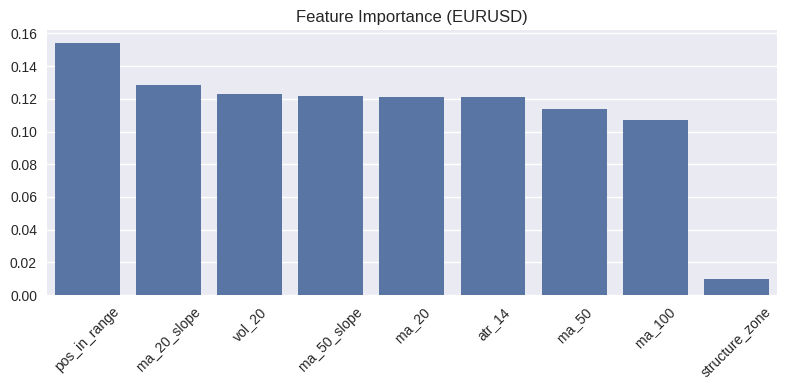

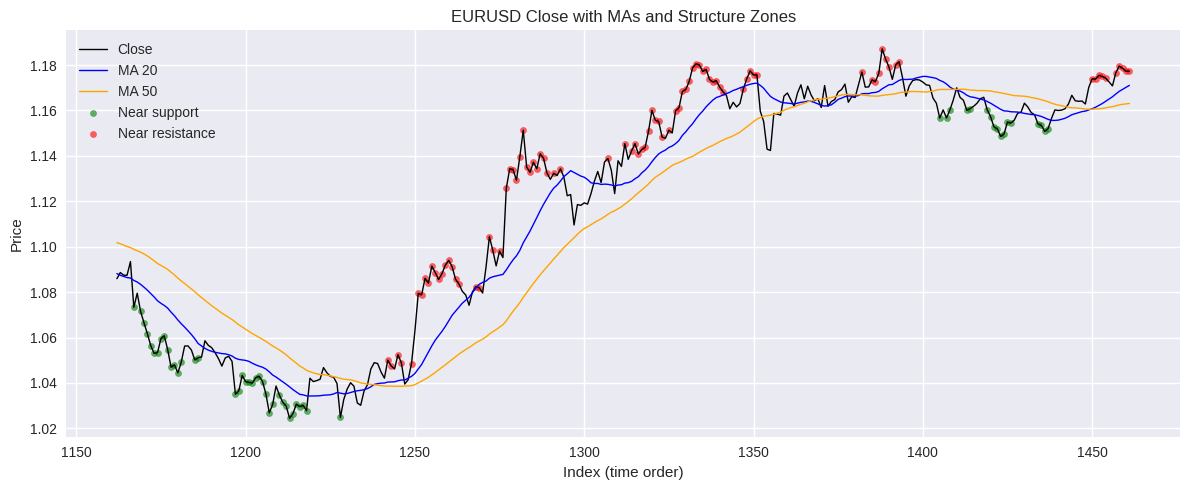


===== XAUUSD (Gold Futures Proxy) RESULTS =====
Accuracy: 0.40070921985815605

Classification Report:
               precision    recall  f1-score   support

           0       0.40      1.00      0.57       113
           1       0.00      0.00      0.00       169

    accuracy                           0.40       282
   macro avg       0.20      0.50      0.29       282
weighted avg       0.16      0.40      0.23       282


Confusion Matrix:
 [[113   0]
 [169   0]]

Feature Importances:
ma_20_slope: 0.1393
atr_14: 0.1304
vol_20: 0.1300
ma_50_slope: 0.1254
pos_in_range: 0.1245
ma_20: 0.1159
ma_50: 0.1144
ma_100: 0.1111
structure_zone: 0.0089


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


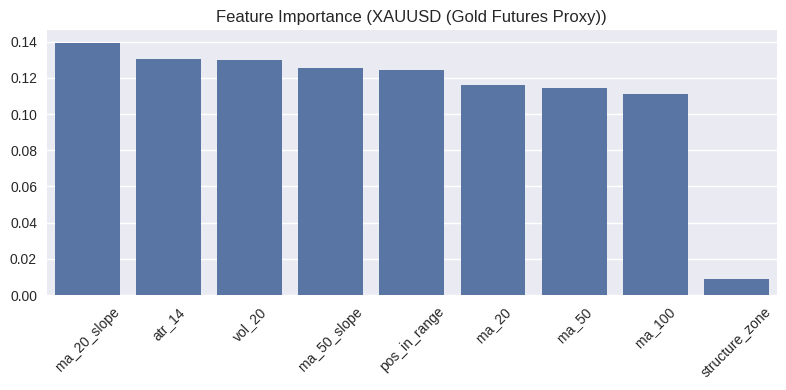

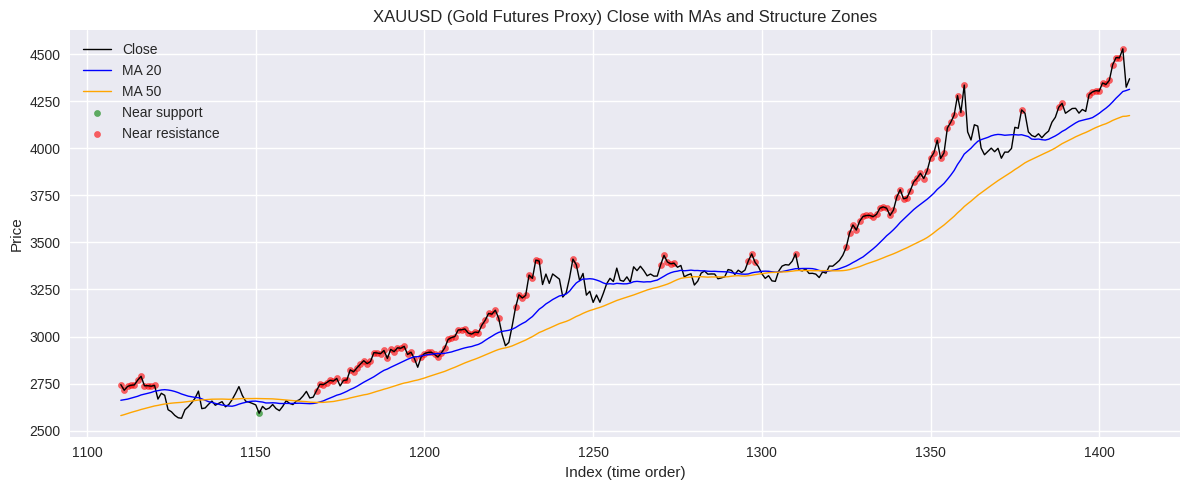


===== BTCUSD RESULTS =====
Accuracy: 0.5083532219570406

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.79      0.61       207
           1       0.53      0.23      0.32       212

    accuracy                           0.51       419
   macro avg       0.52      0.51      0.47       419
weighted avg       0.52      0.51      0.47       419


Confusion Matrix:
 [[164  43]
 [163  49]]

Feature Importances:
pos_in_range: 0.1545
ma_20_slope: 0.1368
ma_50_slope: 0.1269
vol_20: 0.1215
atr_14: 0.1210
ma_100: 0.1161
ma_20: 0.1083
ma_50: 0.1063
structure_zone: 0.0088


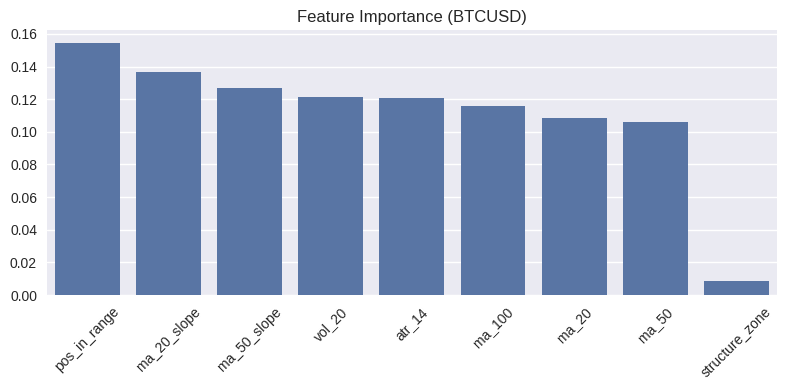

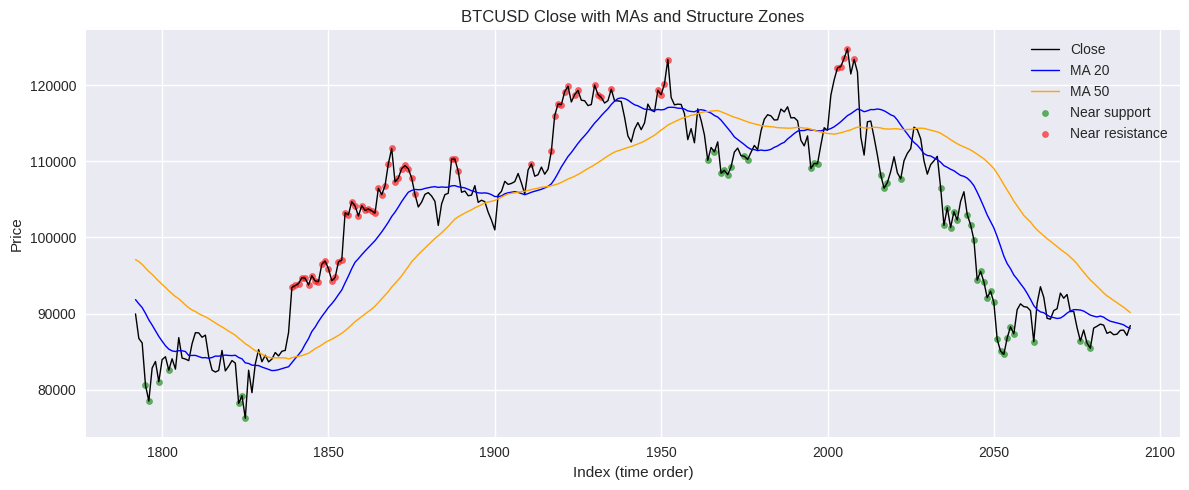

In [13]:
# EURUSD
eurusd_results = run_pipeline_for_asset(eurusd, 'EURUSD')

# XAU (gold proxy)
xau_results = run_pipeline_for_asset(xau, 'XAUUSD (Gold Futures Proxy)')

# BTC
btc_results = run_pipeline_for_asset(btc_df, 'BTCUSD')